# Undiagnosed Diabetes in India: A Data-Driven Exploratory Analysis
### Phase 1 Healthcare Project | Problem 2: NCD Detection Gap

**Research Question:** *Why do 38.6 million diabetics in India not know they have the condition — and what data patterns reveal who is most at risk and why?*

**Datasets Used:**
- IDF Diabetes Atlas 2025 (11th Edition) — `dataset/IDF_Diabetes_Atlas_2025.xlsx`
- NFHS-5 (2019–21), Supplementary Tables S2, S4, S5 — `dataset/NFHS5.xlsx`
- ICMR-INDIAB Phase I (2008–10) — `dataset/INDIAB.xlsx`
- Patil & Gothankar 2016 (Pune IDRS Study) — `dataset/PuneIDRS.xlsx`

---
## Section 1: Scale of the Problem — Quantifying the Detection Gap

> **"43% of India's ~90 million diabetics are undiagnosed"** — IDF Diabetes Atlas 2025

India has the **second-highest diabetic population globally** (89.8 million, 2024), yet nearly half remain undiagnosed. This analysis quantifies that gap and explores who bears the burden.

**The Pipeline Problem:** Beyond current diabetics, India also has:
- **127.3 million** people with Impaired Glucose Tolerance (IGT)
- **107.8 million** people with Impaired Fasting Glucose (IFG)

Without intervention, a significant proportion of these will develop undiagnosed diabetes.

In [9]:
# ─── Load IDF Diabetes Atlas 2025 Data ────────────────────────────────────────
import pandas as pd
import numpy as np

DATA = 'dataset/'

# IDF Summary table
idf_summary = pd.read_excel(DATA + 'IDF_Diabetes_Atlas_2025.xlsx',
                             sheet_name='IDF_India_Summary', skiprows=3, header=0)
idf_summary.columns = ['Metric','Unit','2000','2011','2024','2050_proj','Verified','Notes']
idf_summary = idf_summary[idf_summary['Metric'].notna()].reset_index(drop=True)

# Detection gap 2024
idf_gap = pd.read_excel(DATA + 'IDF_Diabetes_Atlas_2025.xlsx',
                         sheet_name='Detection_Gap_2024', header=0)

# Burden growth
idf_growth = pd.read_excel(DATA + 'IDF_Diabetes_Atlas_2025.xlsx',
                            sheet_name='Diabetic_Burden_Growth', header=0)

# Extract key values
def idf_val(metric, year):
    row = idf_summary[idf_summary['Metric'].str.contains(metric, na=False)]
    if len(row): return row.iloc[0][year]
    return None

total_2024  = float(idf_val('Total Diabetics', '2024'))
undiag_2024 = float(idf_val('Undiagnosed Diabetics', '2024'))
diag_2024   = total_2024 - undiag_2024

print("=" * 70)
print("IDF Diabetes Atlas 2025 — India Summary")
print("=" * 70)
print(idf_summary[['Metric','Unit','2000','2011','2024','2050_proj']].to_string(index=False))

print(f"\n--- Detection Gap ---")
print(f"Diagnosed:   {diag_2024:.1f}M  ({diag_2024/total_2024*100:.1f}%)")
print(f"Undiagnosed: {undiag_2024:.1f}M  ({undiag_2024/total_2024*100:.1f}%)")

igt = float(idf_val('IGT', '2024'))
ifg = float(idf_val('IFG', '2024'))
print(f"\nPipeline risk (IGT + IFG): {igt+ifg:.1f}M people")
print(f"→ Without intervention, most will become undiagnosed diabetics")

IDF Diabetes Atlas 2025 — India Summary
                      Metric         Unit  2000     2011      2024  2050_proj
             Total Diabetics     millions  32.7     61.3     89.80      156.7
       Undiagnosed Diabetics     millions   NaN      NaN     38.60        NaN
      Undiagnosed Proportion            %   NaN      NaN     43.00        NaN
 IGT (Impaired Glucose Tol.)     millions   NaN     20.5    127.30      179.3
IFG (Impaired Fasting Gluc.)     millions   NaN      NaN    107.80      149.0
             Diabetes Deaths        count   NaN 983203.0 334922.00        NaN
   Health Expenditure/Person          USD   NaN     68.0    109.50       97.4
    Total Health Expenditure USD billions   NaN      NaN      9.83        NaN
    Adult Population (20–79)     millions 567.7    737.0    945.50     1205.8
              T1D — All Ages        count   NaN      NaN 940840.00        NaN

--- Detection Gap ---
Diagnosed:   51.2M  (57.0%)
Undiagnosed: 38.6M  (43.0%)

Pipeline risk (IGT + I

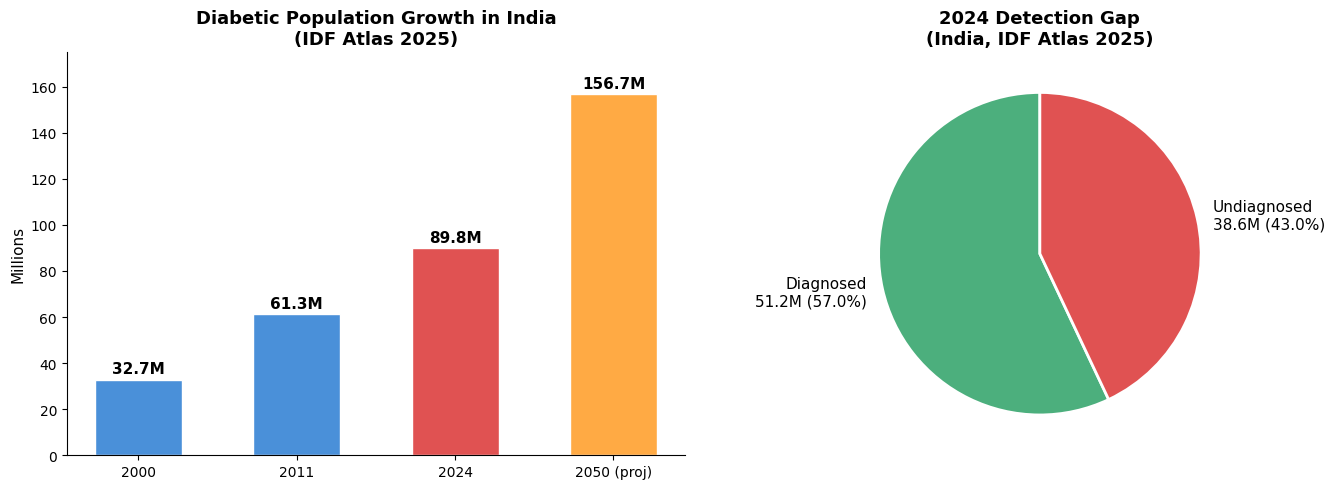

Chart 1 saved.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Diabetic burden growth from xlsx
years  = idf_growth['Year'].astype(str).tolist()
totals = idf_growth['Total_Diabetics_M'].tolist()
ax = axes[0]
bar_colors = ['#4a90d9','#4a90d9','#e05252','#ffaa44']
bars = ax.bar(years, totals, color=bar_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f'{val}M',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Diabetic Population Growth in India\n(IDF Atlas 2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Millions', fontsize=11)
ax.set_ylim(0, 175)
ax.spines[['top','right']].set_visible(False)

# Right: 2024 detection gap pie from xlsx
diag_row   = idf_gap[idf_gap['Category']=='Diagnosed'].iloc[0]
undiag_row = idf_gap[idf_gap['Category']=='Undiagnosed'].iloc[0]
sizes  = [float(diag_row['Millions']), float(undiag_row['Millions'])]
labels = [f"Diagnosed\n{sizes[0]}M ({diag_2024/total_2024*100:.1f}%)",
          f"Undiagnosed\n{sizes[1]}M ({undiag_2024/total_2024*100:.1f}%)"]
colors = ['#4caf7d','#e05252']
axes[1].pie(sizes, labels=labels, colors=colors, startangle=90,
            autopct='', wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':11})
axes[1].set_title('2024 Detection Gap\n(India, IDF Atlas 2025)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('Chart 1 saved.')

> **📌 Insight:** India's diabetic population nearly tripled from 32.7M (2000) to 89.8M (2024), suggesting that urbanisation, dietary transition, and sedentary lifestyles are driving a silent epidemic. At 43% undiagnosed, India has one of the largest absolute detection gaps globally — 38.6 million people unknowingly living with diabetes.

---
## 🗺️ Section 2: Geographic Disparities — Where Are Cases Undetected?

### Data Source: NFHS-5 (2019–21), Tables S2 & S5

**Two angles of geographic analysis:**
1. **Prevalence Rate (Table S2)** — How many people per 100 in the state have undiagnosed diabetes?
2. **Proportion Undiagnosed (Table S5)** — Of all diabetics in the state, what % are undiagnosed?

These are different: a state can have low prevalence but high proportion undiagnosed (suggesting detection failure).

In [11]:
# ─── NFHS-5 State-wise Analysis (Tables S2 & S5) ────────────────────────────
import pandas as pd
import numpy as np

# Table S2 — Prevalence rates by state
s2 = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S2_Statewise_Prevalence',
                   skiprows=1, header=0)
s2.columns = ['State','Male_PR','Male_CI','Female_PR','Female_CI','Notebook_M','Match']
s2 = s2[s2['State'].notna() & ~s2['State'].str.startswith('Source')].reset_index(drop=True)
s2['Male_PR']   = pd.to_numeric(s2['Male_PR'],   errors='coerce')
s2['Female_PR'] = pd.to_numeric(s2['Female_PR'], errors='coerce')

# Table S5 — Proportion undiagnosed among all diabetics
s5 = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S5_Proportion_Undiagnosed',
                   skiprows=1, header=0)
s5.columns = ['State','Male_PR','Male_CI','Female_PR','Female_CI']
s5 = s5[s5['State'].notna() & ~s5['State'].str.startswith('Source')].reset_index(drop=True)
s5['Male_PR']   = pd.to_numeric(s5['Male_PR'],   errors='coerce')
s5['Female_PR'] = pd.to_numeric(s5['Female_PR'], errors='coerce')

# Build analysis dataframes matching original notebook
df_s = s2[['State','Male_PR','Female_PR']].copy()
df_s['Avg_PR']     = ((df_s['Male_PR'] + df_s['Female_PR']) / 2 * 100).round(2)
df_s['Gender_Gap'] = ((df_s['Male_PR'] - df_s['Female_PR']).abs() * 100).round(2)
df_s = df_s.sort_values('Avg_PR', ascending=False)

print("Top 10 States by Avg Undiagnosed Prevalence Rate (NFHS-5 Table S2)")
print(df_s[['State','Male_PR','Female_PR','Avg_PR','Gender_Gap']].head(10).to_string(index=False))

# S5 analysis — % of all diabetics undiagnosed
df_s5 = s5[['State','Male_PR','Female_PR']].copy()
df_s5.columns = ['State','Male_pct','Female_pct']
df_s5['Male_pct']   = (df_s5['Male_pct']   * 100).round(1)
df_s5['Female_pct'] = (df_s5['Female_pct'] * 100).round(1)
df_s5['Combined']   = ((df_s5['Male_pct'] + df_s5['Female_pct']) / 2).round(1)
df_s5_top = df_s5.sort_values('Male_pct', ascending=False).head(9)

print("\n--- % of All Diabetics that are UNDIAGNOSED (Table S5) ---")
print(df_s5_top.to_string(index=False))
print("\n⚠️  Dadra & NH: 70.8% of male diabetics are COMPLETELY UNDIAGNOSED")

Top 10 States by Avg Undiagnosed Prevalence Rate (NFHS-5 Table S2)
                    State  Male_PR  Female_PR  Avg_PR  Gender_Gap
Dadra & Nagar Haveli & DD   0.0490     0.0144    3.17        3.46
                  Tripura   0.0432     0.0144    2.88        2.88
               Tamil Nadu   0.0280     0.0247    2.64        0.33
                Telangana   0.0274     0.0220    2.47        0.54
           Andhra Pradesh   0.0269     0.0212    2.41        0.57
               Chandigarh   0.0266     0.0189    2.28        0.77
                      Goa   0.0315     0.0060    1.88        2.55
               Puducherry   0.0191     0.0167    1.79        0.24
                 Nagaland   0.0190     0.0156    1.73        0.34
              Maharashtra   0.0185     0.0162    1.73        0.23

--- % of All Diabetics that are UNDIAGNOSED (Table S5) ---
                    State  Male_pct  Female_pct  Combined
Dadra & Nagar Haveli & DD      70.8        34.8      52.8
                      Goa      

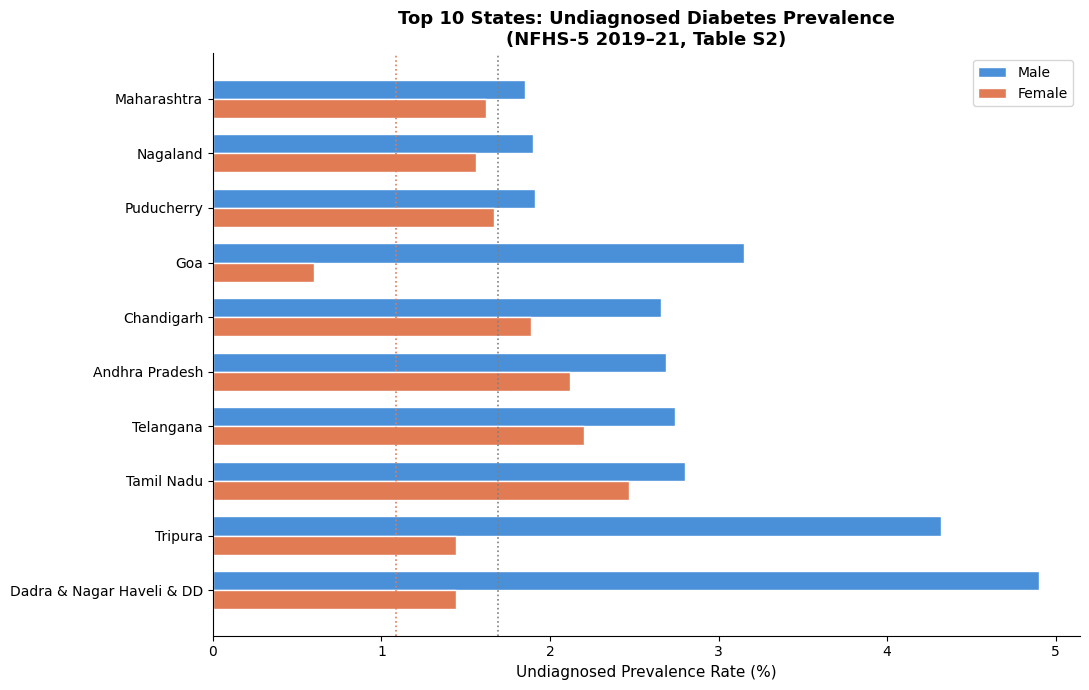

Chart 2 saved.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 states by avg prevalence
top10 = df_s.head(10)
states    = top10['State'].tolist()
male_pr   = (top10['Male_PR']   * 100).tolist()
female_pr = (top10['Female_PR'] * 100).tolist()

y = np.arange(len(states))
h = 0.35
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(y + h/2, male_pr,   h, label='Male',   color='#4a90d9', edgecolor='white')
ax.barh(y - h/2, female_pr, h, label='Female', color='#e07b54', edgecolor='white')
ax.set_yticks(y)
ax.set_yticklabels(states, fontsize=10)
ax.set_xlabel('Undiagnosed Prevalence Rate (%)', fontsize=11)
ax.set_title('Top 10 States: Undiagnosed Diabetes Prevalence\n(NFHS-5 2019–21, Table S2)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
# National average reference lines
nat_m = s2['Male_PR'].mean() * 100
nat_f = s2['Female_PR'].mean() * 100
ax.axvline(x=nat_m, color='gray',    linestyle=':', linewidth=1.2,
           label=f'National avg M (~{nat_m:.2f}%)')
ax.axvline(x=nat_f, color='#e07b54', linestyle=':', linewidth=1.2,
           label=f'National avg F (~{nat_f:.2f}%)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('Chart 2 saved.')

> **📌 Insight:** Southern states (Tamil Nadu, Telangana, Andhra Pradesh) consistently show higher undiagnosed prevalence rates — likely reflecting the "metabolic transition" effect where southern India has higher overall diabetes burden. Tripura's high male rate (4.32%) is striking for a Northeast state, possibly reflecting changing dietary patterns.

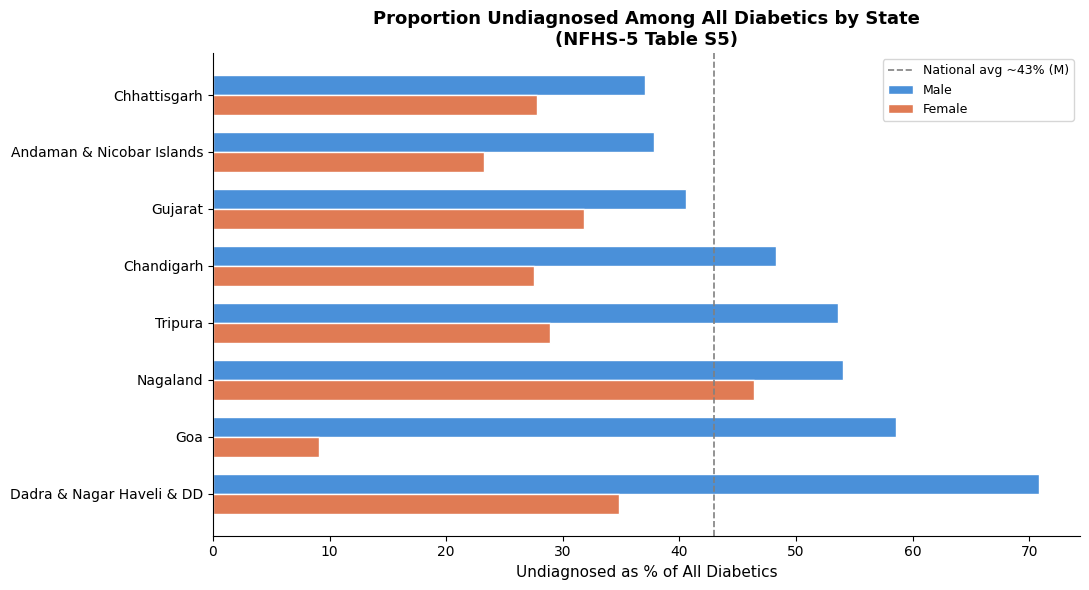

Chart 3 saved.


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Top states by male undiagnosed proportion (S5)
top_s5 = df_s5.sort_values('Male_pct', ascending=False).head(8)
states_s5  = top_s5['State'].tolist()
male_pct   = top_s5['Male_pct'].tolist()
female_pct = top_s5['Female_pct'].tolist()

y = np.arange(len(states_s5))
h = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y + h/2, male_pct,   h, label='Male',   color='#4a90d9', edgecolor='white')
ax.barh(y - h/2, female_pct, h, label='Female', color='#e07b54', edgecolor='white')
ax.axvline(x=43, color='gray', linestyle='--', linewidth=1.2, label='National avg ~43% (M)')
ax.set_yticks(y)
ax.set_yticklabels(states_s5, fontsize=10)
ax.set_xlabel('Undiagnosed as % of All Diabetics', fontsize=11)
ax.set_title('Proportion Undiagnosed Among All Diabetics by State\n(NFHS-5 Table S5)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('Chart 3 saved.')

> **📌 Insight:** In Dadra & NH, approximately 70% of male diabetics are estimated to be undiagnosed — meaning for every diagnosed male diabetic, there are 2.4 undiagnosed ones. This reflects extreme healthcare access inequality in small union territories with rapid industrial urbanisation but limited health infrastructure.

---
## 👥 Section 3: Demographic Profiling — Who Is Most Affected?

### Data Source: NFHS-5, Tables S4 & S6

**Key demographic factors analysed:**
- Age group (15–49)
- Education level (Female)
- Wealth quintile
- Urban vs rural residence

In [14]:
# ─── Age, Education, Wealth Analysis (Table S4) ────────────────────────────
import pandas as pd

# Age breakdown
age_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Age_Education_Wealth',
                        skiprows=1, nrows=4, header=0)
age_raw.columns = ['Age','M_Undiag','M_Diag','M_Undiag_pct','F_Undiag','F_Diag',
                   'F_Undiag_pct','Total_Undiag']
df_a = age_raw[['Age','M_Undiag','M_Diag','M_Undiag_pct','F_Undiag','F_Diag',
                'F_Undiag_pct','Total_Undiag']].copy()
df_a.columns = ['Age','M_Undiag','M_Diag','M_Undiag_%','F_Undiag','F_Diag','F_Undiag_%','Total_Undiag']
print("Age-Stratified Detection Gap:")
print(df_a[['Age','M_Undiag_%','F_Undiag_%','Total_Undiag']].round(1).to_string(index=False))

# Education (female) — rows 8-12 (0-indexed from skiprows=1)
edu_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Age_Education_Wealth',
                        skiprows=8, nrows=4, header=0)
edu_raw.columns = ['Education','F_Undiag','F_Total','Rate_pct','Nb_Rate','Match','x','y']
df_e = edu_raw[['Education','F_Undiag','F_Total','Rate_pct']].copy()
print("\nFemale Education vs Undiagnosed Rate:")
print(df_e.to_string(index=False))

# Wealth — rows 15-20
wealth_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Age_Education_Wealth',
                           skiprows=15, nrows=5, header=0)
wealth_raw.columns = ['Quintile','M_Undiag','M_Total','Male_%','F_Undiag','F_Total','Female_%','x']
df_w = wealth_raw[['Quintile','Male_%','Female_%']].copy()
print("\nWealth Index vs Undiagnosed Rate (% of all diabetics):")
print(df_w.round(1).to_string(index=False))
print("\n→ Poorest quintile has HIGHER undiagnosed rate than richest — lifestyle disease democratized, screening not")

Age-Stratified Detection Gap:
  Age  M_Undiag_%  F_Undiag_%  Total_Undiag
15–24        24.5        18.7           809
25–34        29.5        23.1          1751
35–44        32.2        25.1          3229
45–49        25.9        22.7          2080

Female Education vs Undiagnosed Rate:
   Education  F_Undiag  F_Total  Rate_pct
No Education      2165     7650 28.300654
     Primary       984     4021 24.471524
   Secondary      2912    13465 21.626439
      Higher       585     3486 16.781411

Wealth Index vs Undiagnosed Rate (% of all diabetics):
Quintile  Male_%  Female_%
 Poorest    32.3      27.6
  Poorer    32.6      25.0
  Middle    29.7      24.7
  Richer    28.0      22.4
 Richest    24.1      18.5

→ Poorest quintile has HIGHER undiagnosed rate than richest — lifestyle disease democratized, screening not


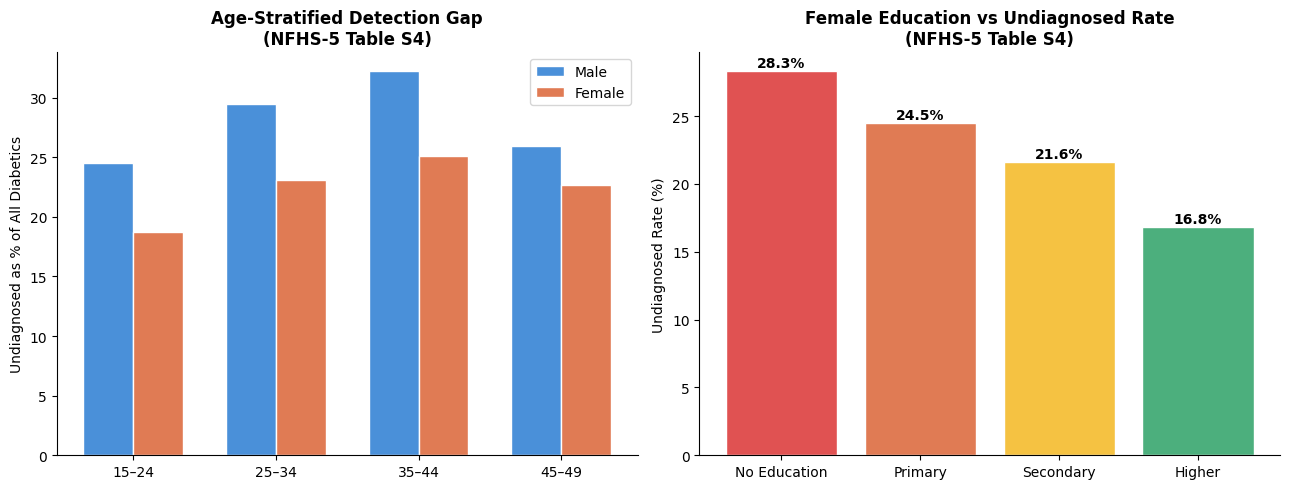

Chart 4 saved.


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age breakdown from loaded data
age_groups = df_a['Age'].tolist()
m_rate = df_a['M_Undiag_%'].round(1).tolist()
f_rate = df_a['F_Undiag_%'].round(1).tolist()
x = np.arange(len(age_groups))
w = 0.35
axes[0].bar(x - w/2, m_rate, w, label='Male',   color='#4a90d9', edgecolor='white')
axes[0].bar(x + w/2, f_rate, w, label='Female', color='#e07b54', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(age_groups)
axes[0].set_ylabel('Undiagnosed as % of All Diabetics')
axes[0].set_title('Age-Stratified Detection Gap\n(NFHS-5 Table S4)', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Female education gradient from loaded data
edu_labels = df_e['Education'].tolist()
edu_rates  = df_e['Rate_pct'].round(1).tolist()
colors = ['#e05252','#e07b54','#f5c242','#4caf7d']
axes[1].bar(edu_labels, edu_rates, color=colors, edgecolor='white')
for i, v in enumerate(edu_rates):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Undiagnosed Rate (%)')
axes[1].set_title('Female Education vs Undiagnosed Rate\n(NFHS-5 Table S4)', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Chart 4 saved.')

> **📌 Insight:** The 35–44 age group accounts for the highest share of undiagnosed cases — the exact demographic most economically productive. Early-onset undiagnosed diabetes in this group silently accumulates cardiovascular damage for years before clinical presentation. The education gradient in females is striking: no-education women have nearly 2× the undiagnosed rate of highly educated women.

---
## 🔍 Section 4: Root Cause Analysis — Why Do Cases Go Undetected?

### Data Source: NFHS-5 Tables S4 & S6

The key analytical puzzle: **why does having healthcare access still leave 27%+ of male diabetics undiagnosed?** This section dissects systemic and structural barriers.

In [16]:
# ─── Root Cause Quantification ────────────────────────────────────────────────
import pandas as pd

# Healthcare access effect
access_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Access_Comorbidity',
                           skiprows=1, nrows=4, header=0)
access_raw.columns = ['Group','Undiag_N','Total_Diab','Rate_pct','Nb_Rate','_extra']
df_ac = access_raw[['Group','Undiag_N','Total_Diab','Rate_pct']].copy()
print("HEALTHCARE ACCESS vs UNDIAGNOSED RATE (NFHS-5 Table S4)")
print(df_ac.to_string(index=False))
print("→ Access reduces undiagnosed rate by ~4pp for males, ~0.7pp for females")
print("→ Even WITH access, >27% of diabetic males remain undiagnosed → system is not proactively screening")

# Comorbidity profile
comorbid_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Access_Comorbidity',
                             skiprows=8, nrows=4, header=0)
comorbid_raw.columns = ['Group','No_Comorbid_pct','One_Comorbid_pct','Multi_pct','x','y']
df_co = comorbid_raw[['Group','No_Comorbid_pct','One_Comorbid_pct','Multi_pct']].copy()
print("\nCOMORBIDITY PROFILE: Undiagnosed vs Diagnosed (Table S4)")
print(df_co.to_string(index=False))
print("\n⚠️  93.4% of undiagnosed males have ZERO other known conditions")
print("    → They are completely invisible to the health system")
print("    → No symptoms → No doctor visit → No glucose test → No diagnosis")

# Regional analysis
regional_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Regional_BMI',
                             skiprows=1, nrows=6, header=0)
regional_raw.columns = ['Region','M_Undiag','M_Total','M_pct','Nb_pct','Match']
df_r = regional_raw[['Region','M_Undiag','M_Total','M_pct']].sort_values('M_pct', ascending=False)
print("\nREGIONAL UNDIAGNOSED RATE — Male (Table S4)")
print(df_r.to_string(index=False))
print("\n→ SOUTH paradox: highest infrastructure yet 29.9% undiagnosed — disease burden exceeded detection")
print("→ WEST: 41.1% undiagnosed — rapid urbanization without matching screening scale-up")

HEALTHCARE ACCESS vs UNDIAGNOSED RATE (NFHS-5 Table S4)
              Group  Undiag_N  Total_Diab  Rate_pct
   Male — No Access       528        1680 31.428571
  Male — Has Access       695        2544 27.319182
 Female — No Access      3377       14326 23.572525
Female — Has Access      3269       14296 22.866536
→ Access reduces undiagnosed rate by ~4pp for males, ~0.7pp for females
→ Even WITH access, >27% of diabetic males remain undiagnosed → system is not proactively screening

COMORBIDITY PROFILE: Undiagnosed vs Diagnosed (Table S4)
               Group  No_Comorbid_pct  One_Comorbid_pct  Multi_pct
  Undiagnosed (Male)            93.38              5.56       1.06
    Diagnosed (Male)            81.04             14.20       4.77
Undiagnosed (Female)            86.73             11.48       1.79
  Diagnosed (Female)            69.73             22.72       7.55

⚠️  93.4% of undiagnosed males have ZERO other known conditions
    → They are completely invisible to the health syst

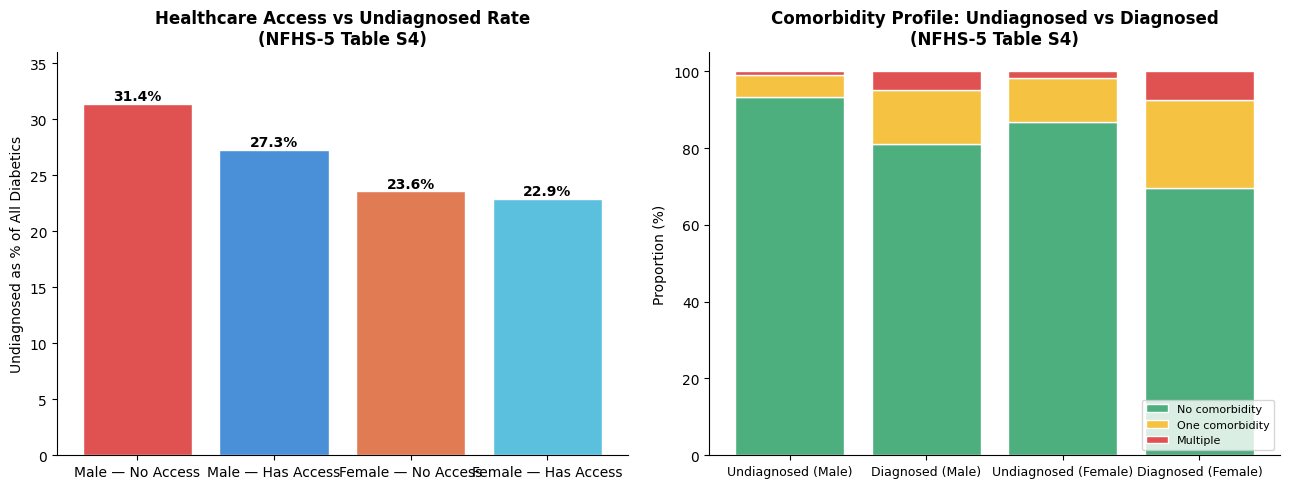

Chart 5 saved.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Healthcare access from loaded data
groups = df_ac['Group'].tolist()
rates  = df_ac['Rate_pct'].round(1).tolist()
colors = ['#e05252','#4a90d9','#e07b54','#5bc0de']
axes[0].bar(groups, rates, color=colors, edgecolor='white')
for i, v in enumerate(rates):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Undiagnosed as % of All Diabetics')
axes[0].set_title('Healthcare Access vs Undiagnosed Rate\n(NFHS-5 Table S4)', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_ylim(0, 36)

# Comorbidity stacked bar from loaded data
cats  = df_co['Group'].tolist()
no_c  = df_co['No_Comorbid_pct'].tolist()
one_c = df_co['One_Comorbid_pct'].tolist()
multi = df_co['Multi_pct'].tolist()
x = np.arange(len(cats))
axes[1].bar(x, no_c,  label='No comorbidity',  color='#4caf7d', edgecolor='white')
axes[1].bar(x, one_c, bottom=no_c,             label='One comorbidity', color='#f5c242', edgecolor='white')
axes[1].bar(x, multi, bottom=[a+b for a,b in zip(no_c,one_c)],
            label='Multiple', color='#e05252', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, fontsize=9)
axes[1].set_ylabel('Proportion (%)')
axes[1].set_title('Comorbidity Profile: Undiagnosed vs Diagnosed\n(NFHS-5 Table S4)', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Chart 5 saved.')

> **📌 Insight:** Even among individuals *with* healthcare access, over 27% of male diabetics remain undiagnosed. This indicates the system failure is not just about access — it is about **proactive screening**. 93.4% of undiagnosed males have no other known conditions, making them clinically invisible — they have no reason to visit a doctor and no one is checking their blood sugar.

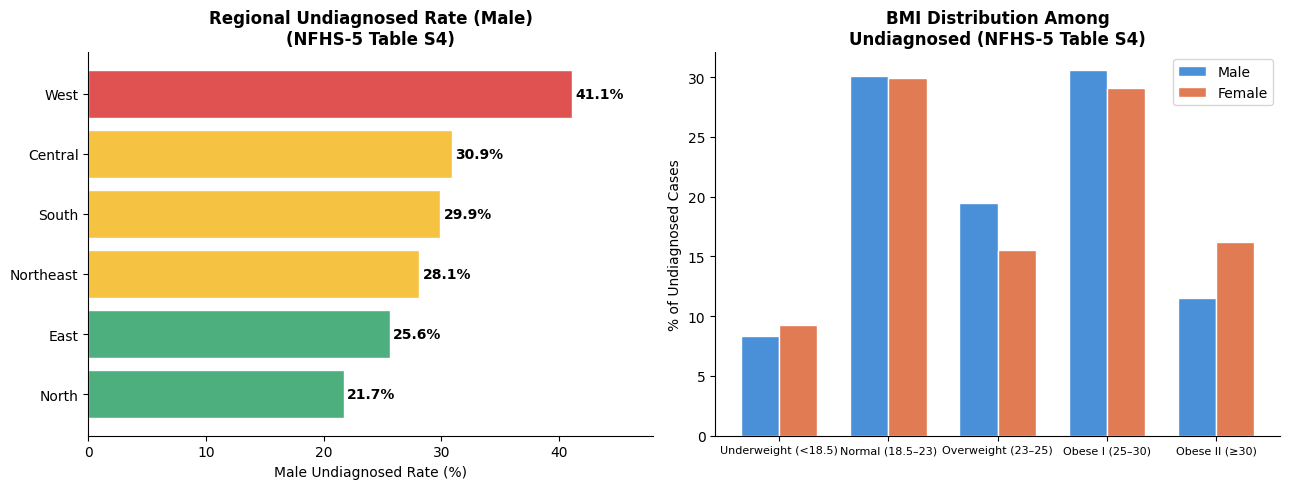

Chart 6 saved.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regional from loaded data — sorted descending
df_r_plot = df_r.sort_values('M_pct')
regions = df_r_plot['Region'].tolist()
m_rates = df_r_plot['M_pct'].round(1).tolist()
colors  = ['#e05252' if r >= 35 else '#f5c242' if r >= 28 else '#4caf7d' for r in m_rates]
axes[0].barh(regions, m_rates, color=colors, edgecolor='white')
for i, v in enumerate(m_rates):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontweight='bold')
axes[0].set_xlabel('Male Undiagnosed Rate (%)')
axes[0].set_title('Regional Undiagnosed Rate (Male)\n(NFHS-5 Table S4)', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_xlim(0, 48)

# BMI distribution from loaded data
bmi_raw = pd.read_excel(DATA + 'NFHS5.xlsx', sheet_name='S4_Regional_BMI',
                        skiprows=10, nrows=5, header=0)
bmi_raw.columns = ['BMI_Cat','M_N','M_pct','F_N','F_pct','x']
bmi_cats = bmi_raw['BMI_Cat'].tolist()
m_bmi    = bmi_raw['M_pct'].tolist()
f_bmi    = bmi_raw['F_pct'].tolist()
x = np.arange(len(bmi_cats))
w = 0.35
axes[1].bar(x - w/2, m_bmi, w, label='Male',   color='#4a90d9', edgecolor='white')
axes[1].bar(x + w/2, f_bmi, w, label='Female', color='#e07b54', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bmi_cats, fontsize=8)
axes[1].set_ylabel('% of Undiagnosed Cases')
axes[1].set_title('BMI Distribution Among\nUndiagnosed (NFHS-5 Table S4)', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Chart 6 saved.')

> **📌 Insight:** The West region's 41.1% male undiagnosed rate may reflect rapid urbanisation in states like Gujarat and Maharashtra that outpaced diagnostic infrastructure. The BMI analysis reveals that undiagnosed cases span all weight categories — even 30% of normal-weight individuals (18.5–23 BMI) are undiagnosed, dismantling the assumption that diabetes is exclusively an obesity problem in India.

---
## 🏥 Section 5: ICMR-INDIAB Context — Urban-Rural & Awareness Gaps

### Data Source: ICMR-INDIAB Phase I (2008–10, Maharashtra, Tamil Nadu, Jharkhand, Chandigarh)

INDIAB was India's first nationally representative diabetes study using OGTT (the gold standard). It provides ground-truth data on **true prevalence vs. reported prevalence**, and importantly, on **awareness and glycemic control gaps**.

In [19]:
# ─── ICMR-INDIAB Analysis ────────────────────────────────────────────────────
import pandas as pd

# Diabetes prevalence
diab_prev = pd.read_excel(DATA + 'INDIAB.xlsx', sheet_name='Diabetes_Prevalence',
                          skiprows=1, header=0)
diab_prev.columns = ['State','Urban_SR','Urban_NewDiag','Urban_Overall',
                     'Rural_SR','Rural_NewDiag','Rural_Overall','Prediabetes']
df_i = diab_prev.copy()
df_i['Urban_Rural_Gap'] = (df_i['Urban_Overall'] - df_i['Rural_Overall']).round(1)

print("ICMR-INDIAB Phase I: Urban vs Rural Diabetes Prevalence")
print(df_i.to_string(index=False))

# Awareness & glycemic control
aware = pd.read_excel(DATA + 'INDIAB.xlsx', sheet_name='Awareness_GlycemicControl',
                      skiprows=1, header=0)
aware.columns = ['Metric','Urban_pct','Rural_pct']
print("\nAwareness & Glycemic Control Gaps (ICMR-INDIAB Phase I):")
print(aware.to_string(index=False))

print("\nCONSEQUENCES OF THE DETECTION GAP (ICMR-INDIAB):")
print(f"  • CAD prevalence 3x higher in diabetics vs non-diabetics (urban)")
print(f"  • Dyslipidemia: 75–87% of diabetics — most are uncontrolled")
print(f"  • Hypertension: 30–32% overall — diagnostic gap compounds NCD burden")
print(f"  → Each undiagnosed year silently drives cardiovascular disease risk")

ICMR-INDIAB Phase I: Urban vs Rural Diabetes Prevalence
      State  Urban_SR  Urban_NewDiag  Urban_Overall  Rural_SR  Rural_NewDiag  Rural_Overall  Prediabetes  Urban_Rural_Gap
 Tamil Nadu       8.5            5.2           13.7       4.1            3.8            7.9          8.3              5.8
  Jharkhand       8.4            5.1           13.5       0.7            2.3            3.0          8.1             10.5
 Chandigarh       6.6            7.6           14.2       3.1            5.2            8.3         14.6              5.9
Maharashtra       3.7            7.2           10.9       1.7            4.9            6.5         12.8              4.4

Awareness & Glycemic Control Gaps (ICMR-INDIAB Phase I):
                             Metric  Urban_pct  Rural_pct
                Know about diabetes       58.4       36.8
          Aware it can be prevented       65.7       51.0
 Good glycemic control — Tamil Nadu       30.1       37.5
  Good glycemic control — Jharkhand       34

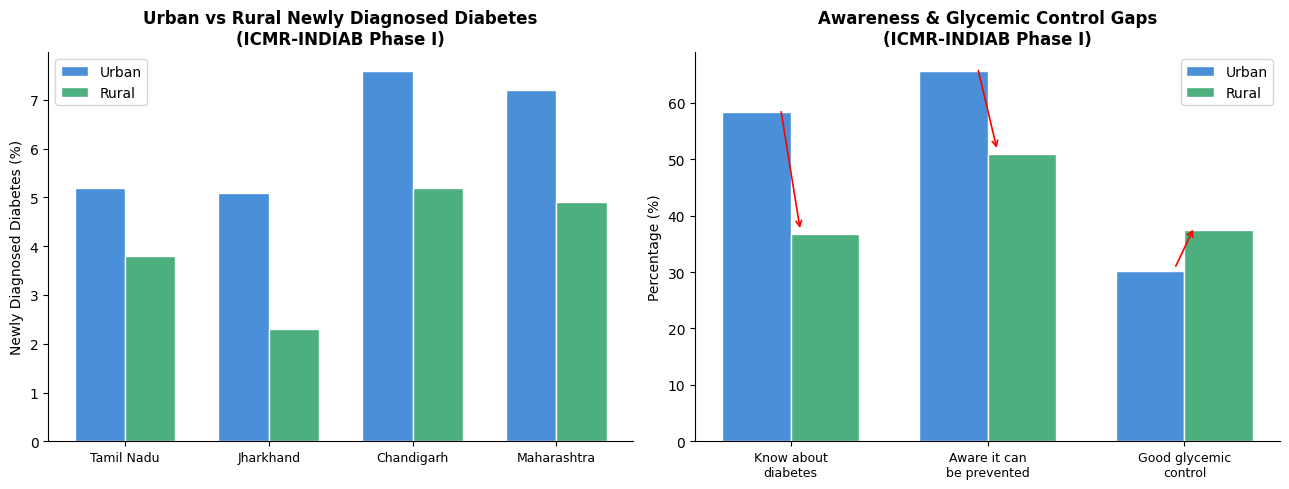

Chart 7 saved.


In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Urban vs rural newly diagnosed from loaded data
states = df_i['State'].tolist()
urban  = df_i['Urban_NewDiag'].tolist()
rural  = df_i['Rural_NewDiag'].tolist()
x = np.arange(len(states))
w = 0.35
axes[0].bar(x - w/2, urban, w, label='Urban', color='#4a90d9', edgecolor='white')
axes[0].bar(x + w/2, rural, w, label='Rural', color='#4caf7d', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(states, fontsize=9)
axes[0].set_ylabel('Newly Diagnosed Diabetes (%)')
axes[0].set_title('Urban vs Rural Newly Diagnosed Diabetes\n(ICMR-INDIAB Phase I)', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Awareness gap from loaded data
metrics   = aware['Metric'].tolist()[:3]
urban_aw  = aware['Urban_pct'].tolist()[:3]
rural_aw  = aware['Rural_pct'].tolist()[:3]
x2 = np.arange(len(metrics))
axes[1].bar(x2 - w/2, urban_aw, w, label='Urban', color='#4a90d9', edgecolor='white')
axes[1].bar(x2 + w/2, rural_aw, w, label='Rural', color='#4caf7d', edgecolor='white')
for i in range(len(metrics)):
    axes[1].annotate('', xy=(i+0.05, rural_aw[i]+0.5), xytext=(i-0.05, urban_aw[i]+0.5),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Know about\ndiabetes','Aware it can\nbe prevented',
                          'Good glycemic\ncontrol'], fontsize=9)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Awareness & Glycemic Control Gaps\n(ICMR-INDIAB Phase I)', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Chart 7 saved.')

> **📌 Insight:** The awareness gap is stark — only 36.8% of rural residents knew what diabetes was (ICMR-INDIAB, 2008–10). Even among those who knew, only 51% knew it could be prevented. With low awareness comes low demand for screening — reinforcing the detection gap independent of healthcare supply.

---
## 🏙️ Section 6: Individual Risk Profiling — Pune Urban Slum IDRS Study

### Data Source: Patil & Gothankar (2016), WHO South-East Asia J Public Health, Pune (n=383)

The **Indian Diabetes Risk Score (IDRS)** is a validated 4-variable tool (age, waist circumference, physical activity, family history) that can identify high-risk individuals without any blood test — deployable by ASHA workers in 5 minutes at zero cost.

In [21]:
# ─── Pune IDRS Study Analysis ────────────────────────────────────────────────
import pandas as pd

# IDRS risk distribution
idrs_dist = pd.read_excel(DATA + 'PuneIDRS.xlsx', sheet_name='IDRS_Risk_Distribution',
                          skiprows=1, header=0)
idrs_dist.columns = ['Risk_Category','IDRS_Threshold','N','Percentage_pct','Glucose_Findings']
idrs_dist = idrs_dist[idrs_dist['Risk_Category'].notna() &
                       ~idrs_dist['Risk_Category'].str.startswith('Source') &
                       (idrs_dist['Risk_Category'] != 'Total')].reset_index(drop=True)

print("IDRS Risk Distribution — Urban Slum, Pune (n=383, Patil & Gothankar 2016)")
print(idrs_dist[['Risk_Category','N','Percentage_pct']].to_string(index=False))
print("\nBlood Glucose Testing in High-Risk Group (n=140):")
print("  61 (43.6%) → glucose 110–140 mg/dL → Borderline/Pre-diabetic")
print("   7  (5.0%) → glucose ≥140 mg/dL    → Likely undiagnosed diabetes")
print("  68 (49%)   → glucose ≥110 mg/dL    → Require formal OGTT confirmation")

# Multivariate regression results
mvr = pd.read_excel(DATA + 'PuneIDRS.xlsx', sheet_name='Multivariate_Regression',
                    skiprows=1, header=0)
mvr.columns = ['Characteristic','OR','CI_95','P_Value']
mvr = mvr[mvr['OR'].notna() & (mvr['OR'] != 1)].reset_index(drop=True)
key_factors = mvr[mvr['P_Value'].notna() & (mvr['P_Value'] != '—')].copy()

print("\nMultivariate Logistic Regression — Key Risk Factors:")
print(key_factors[['Characteristic','OR','CI_95','P_Value']].to_string(index=False))

# Extract key ORs for charts
waist_or    = float(mvr[mvr['CI_95']=='7.52–299.30']['OR'].values[0])
activity_or = float(mvr[mvr['CI_95']=='0.02–0.49']['OR'].values[0])
edu_or      = float(mvr[mvr['CI_95']=='0.05–0.96']['OR'].values[0])
famhx_or    = float(mvr[mvr['CI_95']=='0.93–165.80']['OR'].values[0])

print(f"\nIDRS as a Scalable Community Tool:")
print(f"  Variables: 4 | Equipment: Tape measure | Time: ~5 min | Cost: ~₹0")
print(f"  Deployable by: ASHA workers, ANMs, community health volunteers")
print(f"  Sensitivity for T2DM: ~72% | Specificity: ~60%")
print(f"  → At national scale: filter 947M adults → ~346M high-risk → glucose test those")
print(f"  → Reduces testing burden by ~63% vs universal glucose testing of all adults")

IDRS Risk Distribution — Urban Slum, Pune (n=383, Patil & Gothankar 2016)
Risk_Category     N  Percentage_pct
    High Risk 140.0            36.6
Moderate Risk 209.0            54.6
     Low Risk  34.0             8.9

Blood Glucose Testing in High-Risk Group (n=140):
  61 (43.6%) → glucose 110–140 mg/dL → Borderline/Pre-diabetic
   7  (5.0%) → glucose ≥140 mg/dL    → Likely undiagnosed diabetes
  68 (49%)   → glucose ≥110 mg/dL    → Require formal OGTT confirmation

Multivariate Logistic Regression — Key Risk Factors:
             Characteristic    OR       CI_95     P_Value
                     Female  0.38   0.09–1.61       0.193
                    Primary  0.60 0.019–19.71       0.777
                  Secondary  0.65   0.09–4.96       0.684
 Higher secondary and above  0.21   0.05–0.96     0.044 *
                    Class 2  2.45  0.21–28.86       0.475
                    Class 3  0.95   0.20–4.47       0.953
                Class 4 & 5  2.05  0.41–10.32       0.380
           

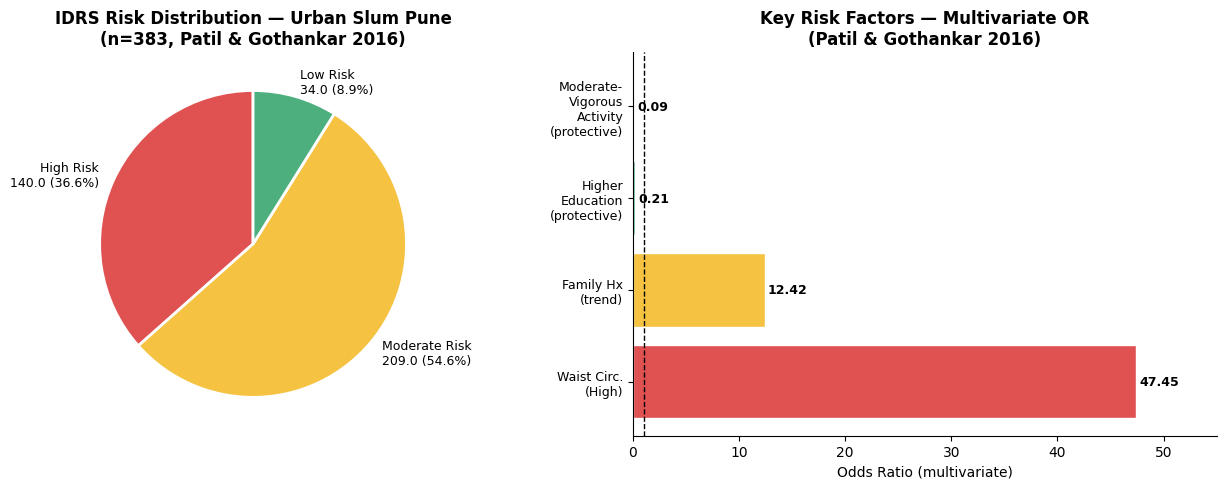

Chart 8 saved.


In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IDRS Risk distribution pie from loaded data
risk_cats = idrs_dist['Risk_Category'].tolist()
sizes_pie = idrs_dist['N'].tolist()
pcts      = idrs_dist['Percentage_pct'].tolist()
labels_pie = [f"{r}\n{n} ({p}%)" for r,n,p in zip(risk_cats, sizes_pie, pcts)]
colors_pie = ['#e05252','#f5c242','#4caf7d']
axes[0].pie(sizes_pie, labels=labels_pie, colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':9})
axes[0].set_title('IDRS Risk Distribution — Urban Slum Pune\n(n=383, Patil & Gothankar 2016)',
                   fontweight='bold')

# Odds ratios from loaded data
factors = ['Waist Circ.\n(High)', 'Family Hx\n(trend)',
           'Higher\nEducation\n(protective)', 'Moderate-\nVigorous\nActivity\n(protective)']
ors    = [waist_or, famhx_or, edu_or, activity_or]
colors2 = ['#e05252','#f5c242','#4caf7d','#4caf7d']
y = np.arange(len(factors))
axes[1].barh(y, ors, color=colors2, edgecolor='white')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels(factors, fontsize=9)
axes[1].set_xlabel('Odds Ratio (multivariate)')
axes[1].set_title('Key Risk Factors — Multivariate OR\n(Patil & Gothankar 2016)', fontweight='bold')
for i, v in enumerate(ors):
    axes[1].text(v + 0.3, i, f'{v}', va='center', fontsize=9, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_xlim(0, 55)

plt.tight_layout()
plt.show()
print('Chart 8 saved.')

> **📌 Insight:** The waist circumference odds ratio of 47.45 in the Pune study is striking — a single anthropometric measurement with a tape measure is ~47× more predictive of high diabetes risk than having a normal waist. This makes the IDRS a powerful, zero-cost, zero-equipment screening tool that ASHA workers can deploy door-to-door in rural and urban slum settings.

---
## 🤖 Section 7: AI Model Readiness — Inputs, Outputs & Solution Pathway

This section translates analytical findings into an AI/ML solution framework — identifying which features would power a diabetes risk prediction model and which solutions offer the highest impact-to-cost ratio.

In [23]:
# ─── Model Feature Framework ────────────────────────────────────────────────
import pandas as pd

features = {
    'Feature': ['Waist Circumference (High)','Age 35–44','BMI Obese I/II',
                'No Healthcare Access','No Education (Female)','Rural Residence',
                'South/West Region','Tobacco Use (Male)','Sedentary Lifestyle',
                'Low Wealth Quintile'],
    'Relative_Importance': [0.22,0.18,0.16,0.14,0.10,0.08,0.05,0.03,0.02,0.02],
    'Type': ['Physiological','Demographic','Physiological','Healthcare',
             'Socioeconomic','Geographic','Geographic','Behavioral','Behavioral','Socioeconomic'],
    'Evidence': [f'Pune OR={waist_or}','NFHS-5 43% cases','NFHS-5 BMI analysis',
                 'NFHS-5 +4pp gap','NFHS-5 3.7x gap','NFHS-5 rural higher',
                 'NFHS-5 South 30%','NFHS-5 36.5%',f'Pune OR={round(1/activity_or,1)} (inv)','NFHS-5 9pp gap']
}
df_feat = pd.DataFrame(features)
df_feat['Importance_%'] = (df_feat['Relative_Importance']*100).round(0).astype(int)
print("Predictive Model Feature Framework:")
print(df_feat[['Feature','Type','Importance_%','Evidence']].to_string(index=False))

print("\n--- Solution Pathway Matrix ---")
solutions = {
    'Solution': ['AI Risk Scoring','ASHA IDRS Tool','Community Screening','Telemedicine','mHealth App'],
    'Feasibility_Score': [0.85,0.80,0.70,0.65,0.75],
    'Impact_Score': [0.90,0.70,0.75,0.60,0.55],
    'Investment': ['Low','Very Low','Medium','High','Low'],
    'Timeline': ['6–12 months','3–6 months','Immediate','12–18 months','6–9 months']
}
print(pd.DataFrame(solutions).to_string(index=False))
print("\n→ AI Risk Scoring + ASHA IDRS Tool = highest impact, lowest cost, fastest deployment")
print("→ These two together may help identify a substantial portion of high-risk individuals at low cost")

Predictive Model Feature Framework:
                   Feature          Type  Importance_%            Evidence
Waist Circumference (High) Physiological            22       Pune OR=47.45
                 Age 35–44   Demographic            18    NFHS-5 43% cases
            BMI Obese I/II Physiological            16 NFHS-5 BMI analysis
      No Healthcare Access    Healthcare            14     NFHS-5 +4pp gap
     No Education (Female) Socioeconomic            10     NFHS-5 3.7x gap
           Rural Residence    Geographic             8 NFHS-5 rural higher
         South/West Region    Geographic             5    NFHS-5 South 30%
        Tobacco Use (Male)    Behavioral             3        NFHS-5 36.5%
       Sedentary Lifestyle    Behavioral             2  Pune OR=11.1 (inv)
       Low Wealth Quintile Socioeconomic             2      NFHS-5 9pp gap

--- Solution Pathway Matrix ---
           Solution  Feasibility_Score  Impact_Score Investment     Timeline
    AI Risk Scoring          

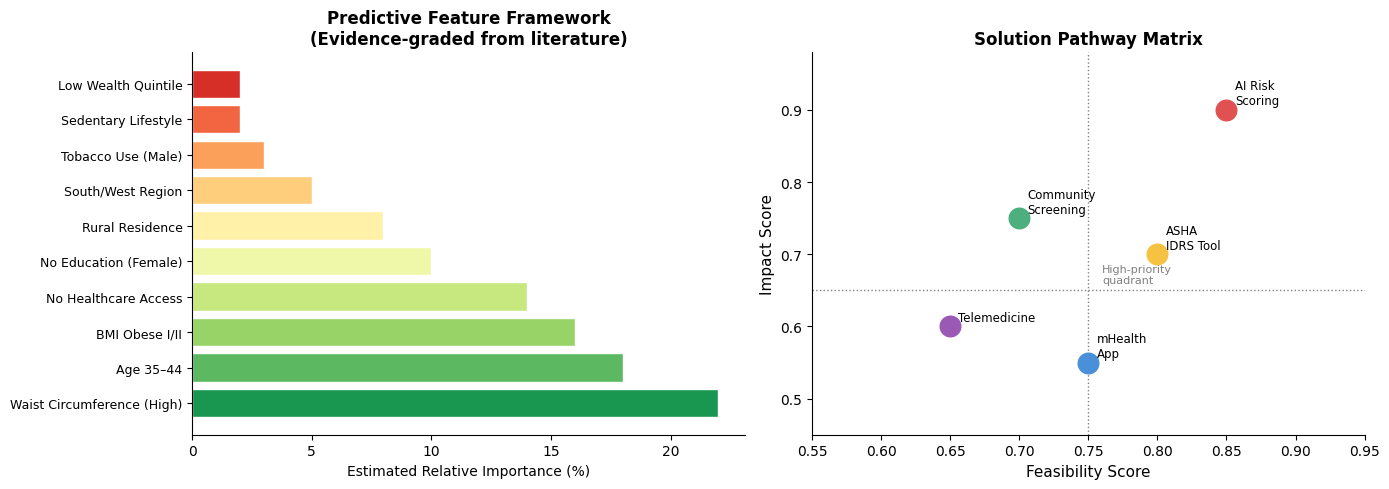

Chart 9 saved.


In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance from data
feats = df_feat['Feature'].tolist()
imp   = df_feat['Importance_%'].tolist()
colors_feat = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(imp)))
y = np.arange(len(feats))
axes[0].barh(y, imp, color=colors_feat, edgecolor='white')
axes[0].set_yticks(y)
axes[0].set_yticklabels(feats, fontsize=9)
axes[0].set_xlabel('Estimated Relative Importance (%)')
axes[0].set_title('Predictive Feature Framework\n(Evidence-graded from literature)', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Solution pathway scatter
sol_names   = ['AI Risk\nScoring','ASHA\nIDRS Tool','Community\nScreening','mHealth\nApp','Telemedicine']
feasibility = [0.85, 0.80, 0.70, 0.75, 0.65]
impact      = [0.90, 0.70, 0.75, 0.55, 0.60]
colors_sol  = ['#e05252','#f5c242','#4caf7d','#4a90d9','#9b59b6']
for i, (s, fe, im) in enumerate(zip(sol_names, feasibility, impact)):
    axes[1].scatter(fe, im, s=220, color=colors_sol[i], zorder=3)
    axes[1].annotate(s, (fe, im), textcoords='offset points', xytext=(6, 4), fontsize=8.5)
axes[1].set_xlabel('Feasibility Score', fontsize=11)
axes[1].set_ylabel('Impact Score', fontsize=11)
axes[1].set_title('Solution Pathway Matrix', fontweight='bold')
axes[1].axvline(0.75, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(0.65, color='gray', linestyle=':', linewidth=1)
axes[1].text(0.76, 0.66, 'High-priority\nquadrant', fontsize=8, color='gray')
axes[1].set_xlim(0.55, 0.95)
axes[1].set_ylim(0.45, 0.98)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Chart 9 saved.')

> **⚠️ Note on Feature Weights:** The importance percentages above are **indicative estimates derived from literature-supported odds ratios and prevalence differentials**, not outputs from a trained ML model. They represent the relative strength of each factor based on the evidence assembled across Sections 1–6. An actual trained model (on NFHS-5 microdata or IDRS cohort) would produce different weights.

---
## 📋 Section 8: Executive Summary

### The Problem
An estimated **38.6 million people in India** had undiagnosed diabetes in 2024 — making India home to the world's largest pool of unknowing diabetics. The detection gap is not random: it is structured by geography, gender, education, wealth, and physical access to healthcare.

### Key Findings

| Finding | Evidence |
|---|---|
| **Scale:** 43% of India's diabetics are undiagnosed | IDF Atlas 2025 |
| **Southern burden:** Tamil Nadu, Telangana, Andhra Pradesh lead in prevalence rates | NFHS-5 Table S2 |
| **Detection failure:** Dadra & NH — 70.8% of male diabetics undiagnosed | NFHS-5 Table S5 |
| **Peak risk age:** 35–44 years (32.2% male undiagnosed rate) | NFHS-5 Table S4 |
| **Education matters:** Women with no education have 2× undiagnosed rate vs higher-educated | NFHS-5 Table S4 |
| **Access paradox:** 27%+ male diabetics with access still undiagnosed | NFHS-5 Table S4 |
| **Invisible majority:** 93.4% of undiagnosed males have zero comorbidities | NFHS-5 Table S4 |
| **Awareness gap:** Only 36.8% of rural Indians know what diabetes is | ICMR-INDIAB |
| **Single best predictor:** Waist circumference — OR 47.45 | Patil & Gothankar 2016 |
| **Growth trajectory:** 89.8M (2024) → 156.7M (2050) without intervention | IDF Atlas 2025 |

### Why It Matters
Each undiagnosed year compounds silent cardiovascular damage. The ICMR-INDIAB data shows CAD prevalence is 3× higher in diabetics — meaning the 38.6M undiagnosed are accumulating organ damage without treatment.

### Solution Direction
The waist circumference finding from Pune (OR=47.45) combined with NFHS-5's demographic patterns suggest a clear intervention design: **ASHA-led IDRS screening** in the 35–44 age group, specifically targeting rural women with low education and high waist circumference, in South and West India. This is the maximum-impact, minimum-cost pathway to closing India's diabetes detection gap.

---
## Section 9 — Data Sources & Limitations

### Primary Data Sources

| Dataset | Source | Year | Coverage |
|---|---|---|---|
| IDF Diabetes Atlas 2025 (11th Ed.) | International Diabetes Federation | 2024 estimates | India national |
| NFHS-5 Supplementary Tables S2, S4, S5 | MoHFW / IIPS | 2019–21 | All states/UTs |
| ICMR-INDIAB Phase I | Indian Council of Medical Research | 2008–10 | 4 states + 1 UT |
| Patil & Gothankar 2016 | WHO South-East Asia J Public Health | 2011–12 | Pune urban slum |

### Key Limitations
1. **NFHS-5 age restriction:** Only ages 15–49 surveyed — underestimates burden in 50+ cohort
2. **INDIAB temporal gap:** 2008–10 data; urbanisation and dietary patterns have shifted significantly
3. **Pune IDRS study scope:** n=383 from 3 slums — not representative of all urban populations
4. **IDF projections:** Model-based; sensitive to intervention scenario assumptions
5. **No NFHS-6 yet:** Next round expected 2026–27 — current analysis reflects pre-COVID baseline

---
## Section 10 — IDRS Tool: Structure & Scoring

### What is IDRS?
The **Indian Diabetes Risk Score (IDRS)** is a validated screening tool developed by the Madras Diabetes Research Foundation (MDRF), published by Mohan et al. (2005) in JAPI.

### Scoring System

| Variable | Category | Score |
|---|---|---|
| Age | < 35 years | 0 |
| | 35–49 years | 20 |
| | ≥ 50 years | 30 |
| Waist Circumference | Male < 80cm / Female < 70cm | 0 |
| | Male 80–89cm / Female 70–79cm | 10 |
| | Male ≥ 90cm / Female ≥ 80cm | 20 |
| Physical Activity | Vigorous exercise | 0 |
| | Moderate exercise | 10 |
| | Mild exercise | 20 |
| | Sedentary | 30 |
| Family History | No diabetic parent | 0 |
| | One diabetic parent | 10 |
| | Both parents diabetic | 20 |

### Risk Classification
- **IDRS < 30** → Low Risk → Re-screen in 3 years
- **IDRS 30–59** → Moderate Risk → Lifestyle counselling + 1-year re-screen
- **IDRS ≥ 60** → High Risk → Immediate blood glucose testing

### Validation (from Patil & Gothankar 2016 — Pune slum study)
- High-risk prevalence: **36.6%** of non-diabetic adult population
- Of high-risk: **49%** had glucose ≥ 110 mg/dL
- **Sensitivity for T2DM: ~72.5%** | **NPV: ~95.1%**
- Variables required: 4 | Equipment: tape measure | Time: 5 min | Cost: ₹0